In [3]:
import sys
import os
sys.path.append(os.path.abspath("../clean_code/"))

In [9]:
from Visualization import generalVisualization
from Visualization import mnistVisuals
from Visualization import visualHelpers
from Utilities import config
import pickle
import select_landmarks_MI
import importlib
import voltagemap
import main
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
from sklearn.manifold import MDS

In [5]:
with open('../../Voltage_Temp/Results/voltage_map.npy', 'rb') as f:
    data_to_save=pickle.load(f)

In [13]:
def transform(points, transformation):
    if transformation == "mds":
        mds = MDS(n_components=2)
        return mds.fit_transform(points)
    elif transformation == "pca":
        pca = PCA(n_components=2)
        return pca.fit_transform(points)
    else:
        raise ValueError("transformation must be either \"pca\" or \"mds\"")

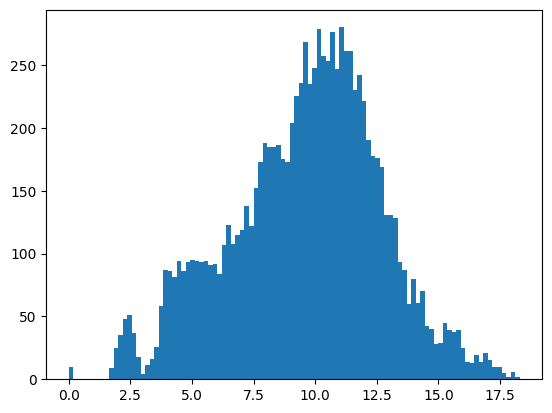

In [27]:
entries = data_to_save['voltage_map'].entries
voltages = []
for entry in entries:
    voltages.append(-np.log(entry['voltages']))

plt.hist(np.array(voltages).flatten(), bins=100);

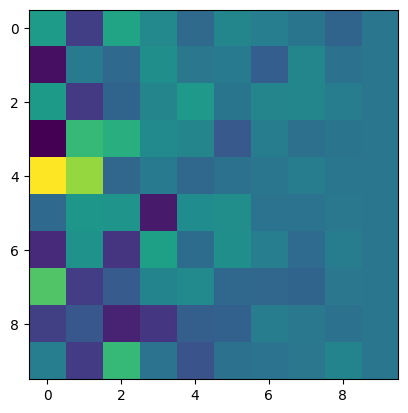

In [31]:
pca = PCA(n_components=10)
plt.imshow(pca.fit_transform(voltages))

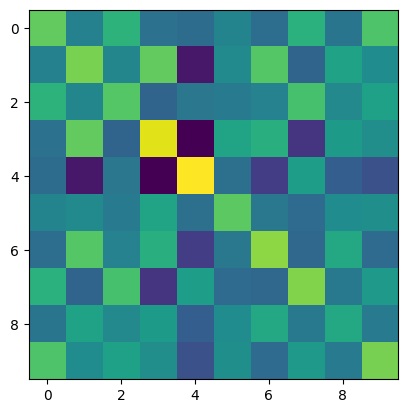

In [33]:
plt.imshow(np.cov(voltages))

In [34]:
def plot_mnist_unlabeled(voltages, data, transformation="mds", landmarkSize=3, alpha_actual=1, percent_size=0.02, out_file=None):
    """
    Draws the MNIST digits corresponding to each point after reducing the dimention to 2 by either PCA or MDS

    Args:
        voltages (VoltageMap): The digits to plot
        data (SetOfPoints): The digits to plot
        landmarkSize (Optional[float]): How much bigger should landmarks be?
        alpha_actual (Optional[float]): The opacity of each digit, 1 is fully opaque and 0 is fully transparent
        percent_size (Optional[float]): The size of each digit, 1 is the size of the whole space and 0 is no image size
        out_file (Optional[str]): If provided, the output path to save the figure (e.g., "digits.png")
    """

    points = voltages.voltage_array()[:, 3:5]
    points = -np.log(points)

    transformed_points = transform(points, transformation)

    fig, ax = plt.subplots(figsize=(12, 10))

    colors = visualHelpers.get_distinct_colors(points[0].shape[0])
    
    x_bound = (transformed_points[:, 0].min(), transformed_points[:, 0].max())
    y_bound = (transformed_points[:, 1].min(), transformed_points[:, 1].max())

    image_size = (x_bound[1] + y_bound[1] - x_bound[0] - y_bound[0]) * percent_size / 2
    
    for i in range(transformed_points.shape[0]):
        alpha_mask = np.clip(data[i].reshape(28, 28), 0, 255) / 255

        point_voltages = points[i]
        
        color = np.array(colors[np.argmax(point_voltages)])

        size = 1
        if (np.max(point_voltages) == 1):
            size = landmarkSize
            color = np.array([1, 1, 1])
        
        # Create RGBA image
        rgb_image = np.zeros((28, 28, 4))
        for c in range(3):
            rgb_image[..., c] = color[c]
        rgb_image[..., 3] = alpha_mask * alpha_actual  # Alpha from pixel intensity

        x, y = transformed_points[i]
        ax.imshow(rgb_image, extent=(x - image_size * size, x + image_size * size, y - image_size * size, y + image_size * size), origin='upper')
    
    ax.set_xlim(x_bound[0] - image_size * landmarkSize, x_bound[1] + image_size * landmarkSize)
    ax.set_ylim(y_bound[0] - image_size * landmarkSize, y_bound[1] + image_size * landmarkSize)
    ax.set_facecolor('black')
    fig.patch.set_facecolor('black')
    plt.title("Visualization of K-Means MNIST")

    visualHelpers.standard_save_display(out_file)

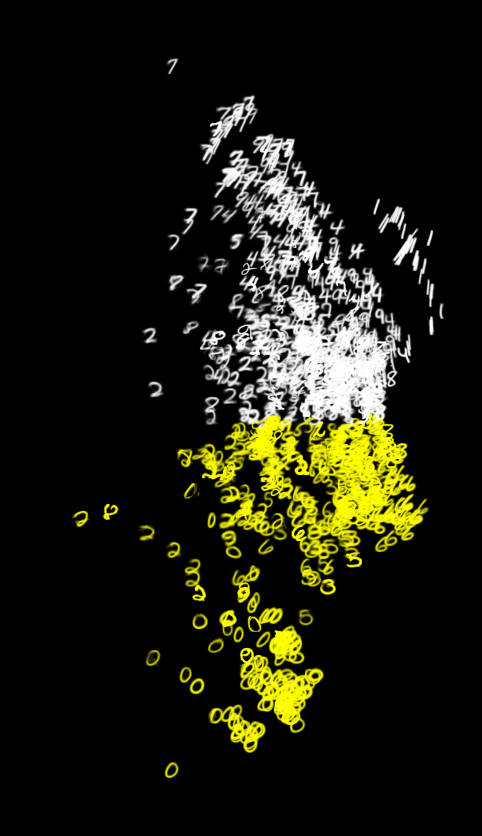

In [35]:
plot_mnist_unlabeled(data_to_save['voltage_map'], data_to_save['centroids'])